# House Price Prediction Project 

## Project Overview

This project builds an end-to-end machine learning system for predicting house prices.

The project covers:
- Data exploration and cleaning
- Exploratory Data Analysis (EDA)
- Feature engineering
- Regression model training and evaluation
- Model export
- FastAPI deployment
- React frontend integration

## 1. Import Libraries


In [3]:
# core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Data Split and Preprocessing
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


# Model Validation and Tuning
from sklearn.model_selection import cross_val_score, RandomizedSearchCV


# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

# Model Saving
import joblib

from IPython.display import FileLink
import json


## 2. Load Dataset


In [4]:
df = pd.read_csv('/kaggle/input/datasets/juhibhojani/house-price/house_prices.csv')

In [5]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [6]:
df.shape

(187531, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [8]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [9]:
df.describe(include='O').T

,count,unique,top,freq
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106
Description,184508,65634,Multistorey apartment is available for sale. I...,2732
Amount(in rupees),187531,1561,Call for Price,9684
location,187531,81,new-delhi,27599
Carpet Area,106858,2758,1000 sqft,5285
Status,186916,1,Ready to Move,186916
Floor,180454,947,2 out of 4,12433
Transaction,187448,4,Resale,144172
Furnishing,184634,3,Semi-Furnished,88318
facing,117298,8,East,54741


In [10]:
null_summary = pd.DataFrame({
    "Null count" : df.isna().sum(),
    "Null %" : (df.isna().mean() * 100).round(3)
    }).sort_values("Null %", ascending=False)

null_summary.head(10)

,Null count,Null %
Plot Area,187531,100.000
Dimensions,187531,100.000
Society,109678,58.485
Super Area,107685,57.423
Car Parking,103357,55.115
overlooking,81436,43.425
Carpet Area,80673,43.018
facing,70233,37.451
Ownership,65517,34.937
Balcony,48935,26.094


In [11]:
df.duplicated().sum()

np.int64(0)

## 3. Target Variable Analysis & Cleaning
I extract numerical values from the 'Amount' column, handle different currency units (Lac, Cr), and evaluate the distribution of the target variable

In [12]:
amount = df['Amount(in rupees)'].str.strip()

In [13]:
value = pd.to_numeric(amount.str.extract(r'([\d.]+)')[0], errors='coerce')
unit = amount.str.extract(r'([a-zA-Z]+)')[0].str.lower()

In [14]:
unit.value_counts()

0
lac     112568
cr       65279
call      9684
Name: count, dtype: int64

In [15]:
unit_replace = {
    'lac' : 100_000,
    'cr' : 10_000_000,
    'call' : np.nan
}

df['Amount(in rupees)'] = value * unit.map(unit_replace)

In [16]:
df = df.dropna(subset=['Amount(in rupees)'])

In [17]:
df.shape

(177847, 21)

In [18]:
df['Amount(in rupees)'].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: Amount(in rupees), dtype: float64

In [19]:
print(f' Skew: {df['Amount(in rupees)'].skew()}')
print(f' Log1p Skew: {np.log1p(df['Amount(in rupees)']).skew()}')

 Skew: 270.25594003798835
 Log1p Skew: 0.2887446834646918


## 4. Exploratory Data Analysis (EDA)

In [20]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",4200000.0,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,9800000.0,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,14000000.0,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,2500000.0,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",16000000.0,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [21]:
df.columns.tolist()

['Index',
 'Title',
 'Description',
 'Amount(in rupees)',
 'Price (in rupees)',
 'location',
 'Carpet Area',
 'Status',
 'Floor',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Society',
 'Bathroom',
 'Balcony',
 'Car Parking',
 'Ownership',
 'Super Area',
 'Dimensions',
 'Plot Area']

#### Target EDA

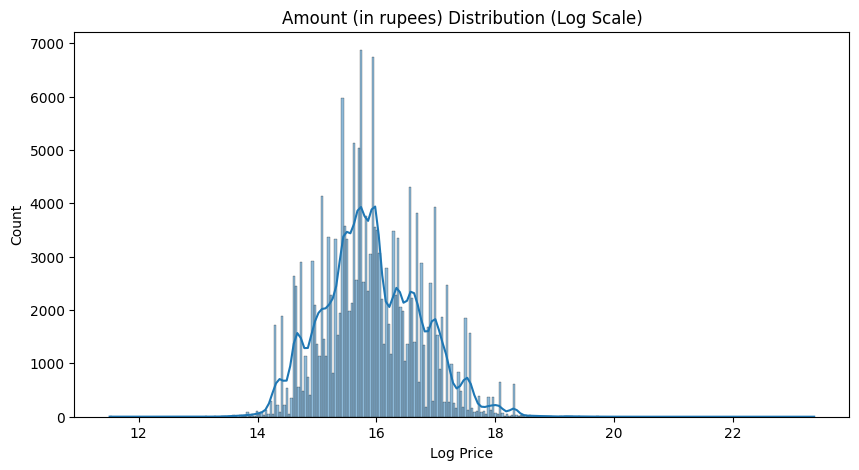

In [22]:
plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(df['Amount(in rupees)']),
    kde=True
)

plt.title('Amount (in rupees) Distribution (Log Scale)')
plt.xlabel('Log Price')
plt.show()

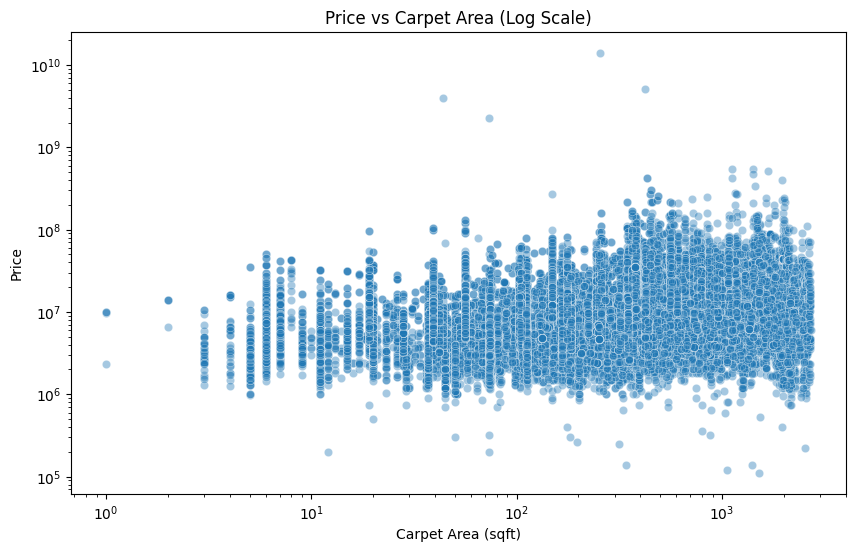

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='Carpet Area', y='Amount(in rupees)', alpha=0.4)

plt.xscale('log')
plt.yscale('log')

plt.title('Price vs Carpet Area (Log Scale)')
plt.xlabel('Carpet Area (sqft)')
plt.ylabel('Price')
plt.show()

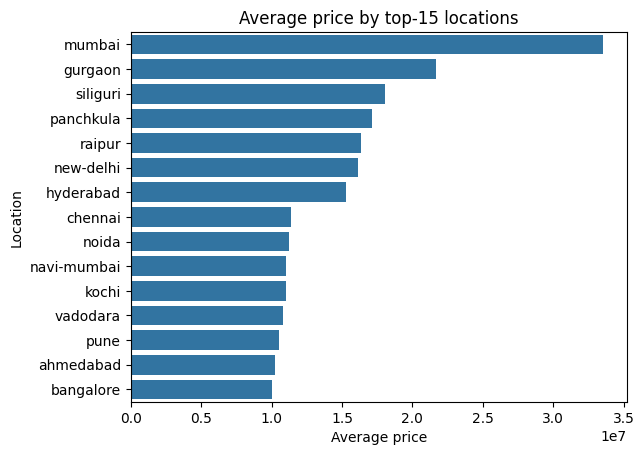

In [24]:
top_15 = (df.groupby)('location')['Amount(in rupees)'].mean().sort_values(ascending=False).head(15)

sns.barplot(x=top_15.values, y=top_15.index)
plt.title('Average price by top-15 locations')
plt.xlabel("Average price")
plt.ylabel("Location")
plt.show()

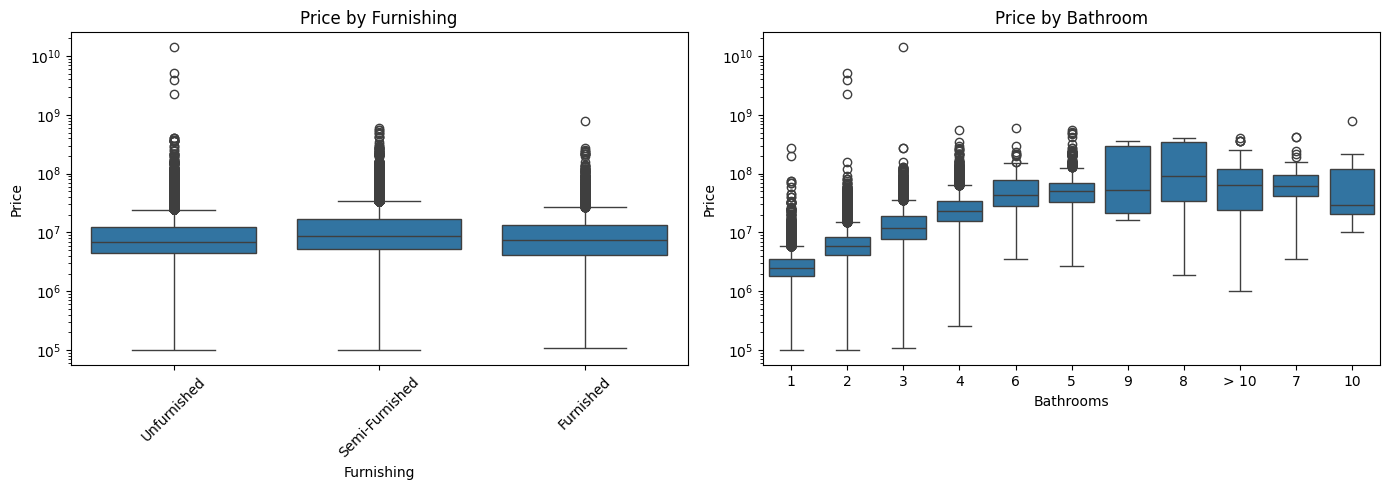

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Furnishing', y='Amount(in rupees)', ax=axes[0])

axes[0].set_title('Price by Furnishing')
axes[0].set_xlabel('Furnishing')
axes[0].set_ylabel('Price')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_yscale('log')


sns.boxplot(data=df, x='Bathroom', y='Amount(in rupees)', ax=axes[1])

axes[1].set_title('Price by Bathroom')
axes[1].set_xlabel('Bathrooms')
axes[1].set_ylabel('Price')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

### Numerical Columns

In [26]:
num_cols = ['Bathroom', 'Balcony']

In [27]:
for col in num_cols:
    print(df[col].value_counts())

Bathroom
2       88999
3       54187
1       15509
4       14826
5        3281
6         187
7          32
> 10       29
8          14
10         12
9          11
Name: count, dtype: int64
Balcony
2       50311
1       45145
3       24958
4        9275
5         814
6         127
> 10       16
7          14
10         13
8          13
9           2
Name: count, dtype: int64


In [28]:
for col in ['Bathroom', 'Balcony']:
    df[col] = df[col].replace('> 10', 11)
    df[col] = pd.to_numeric(df[col], errors = 'coerce')

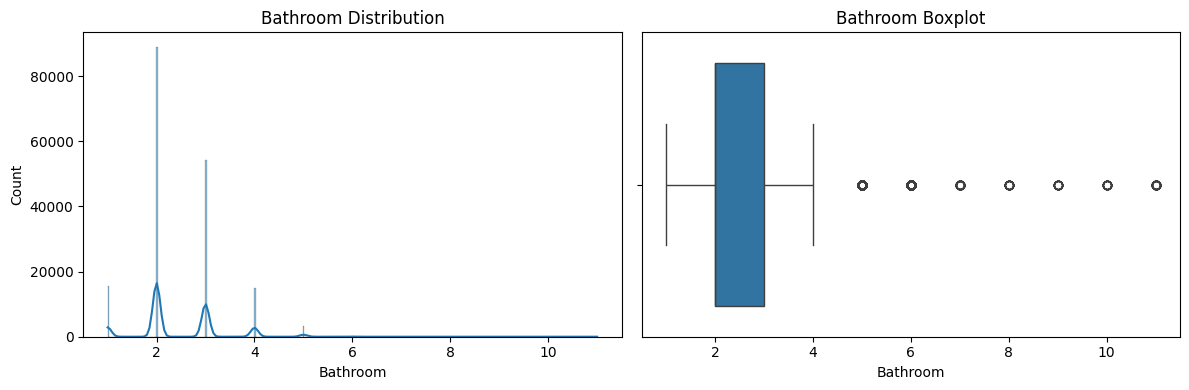

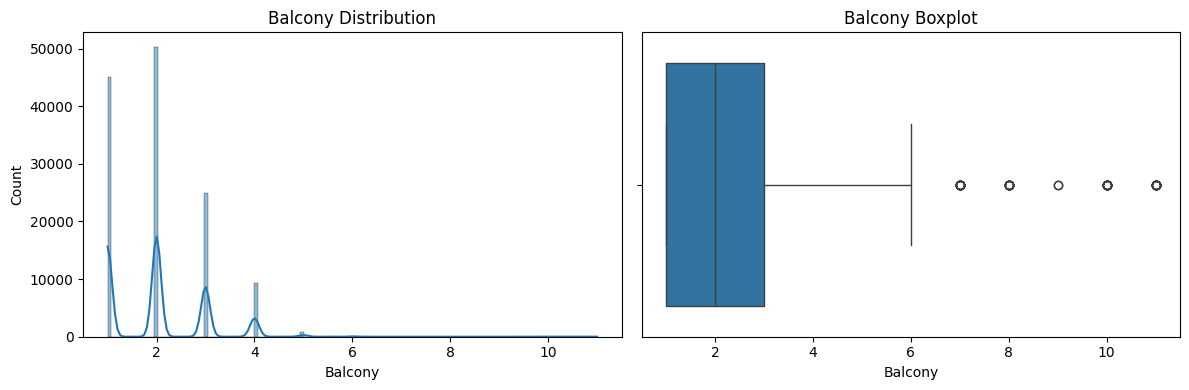

In [29]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(data=df, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f'{col} Distribution')

    sns.boxplot(data=df, x=col, ax=axes[1])
    axes[1].set_title(f'{col} Boxplot')

    plt.tight_layout()
    plt.show()

### Numerical Features

- **Bathroom:** Most houses have 2–3 bathrooms, with very few missing values. The distribution is slightly right-skewed.
- **Balcony:** Most houses have 1–3 balconies. It has a higher percentage of missing values and is also slightly right-skewed.

### Categorical colsums

In [30]:
small_plot_cols = ['Transaction', 'Furnishing', 'facing', 'Ownership']
large_plot_cols = ['location', 'overlooking']

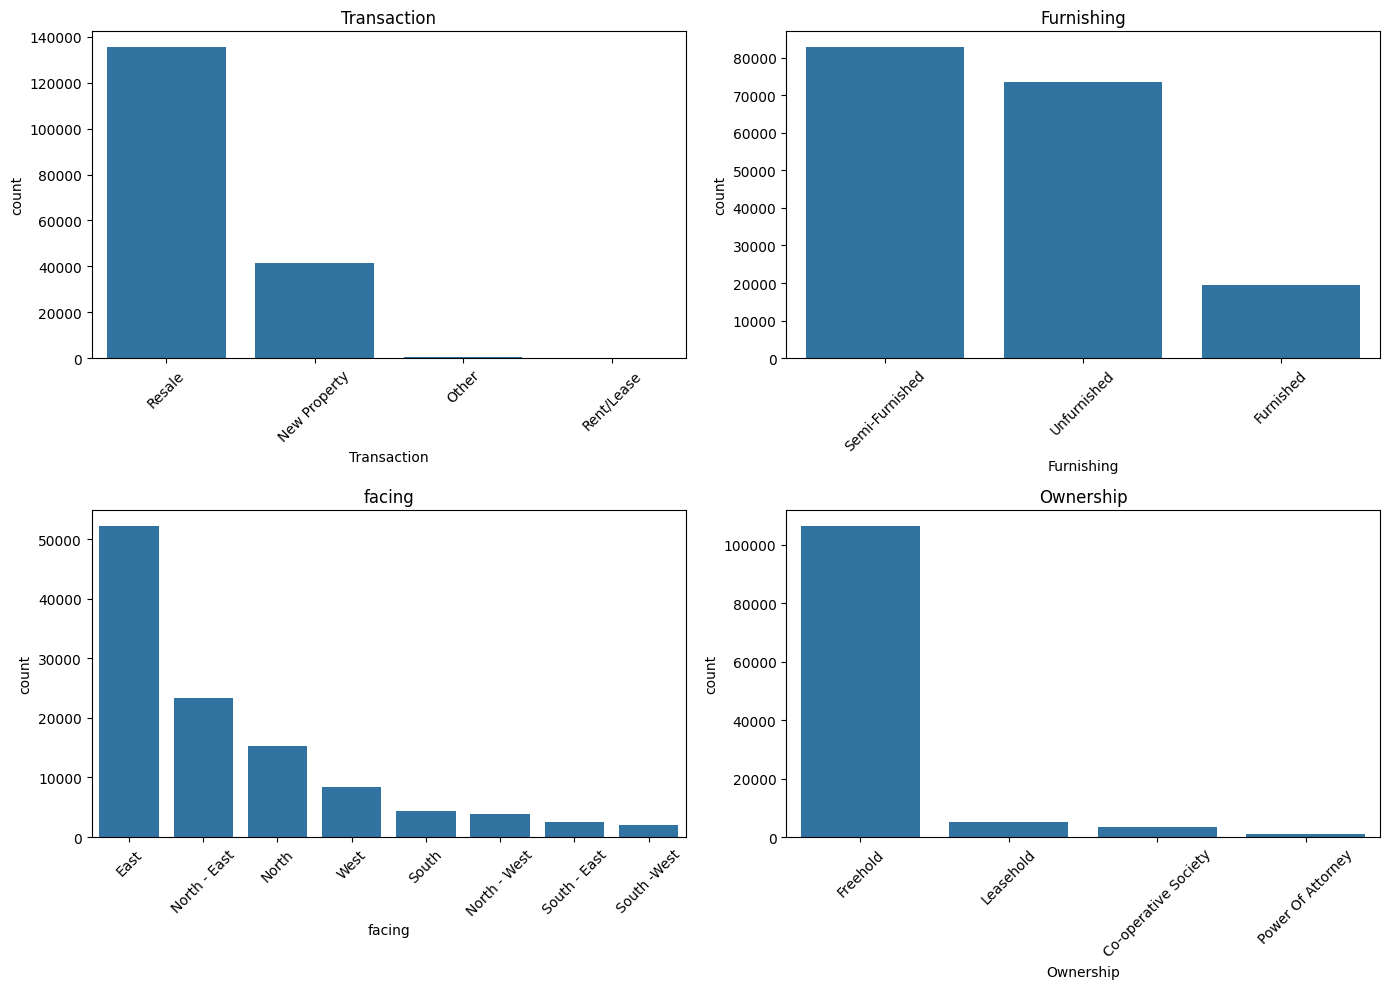

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, small_plot_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

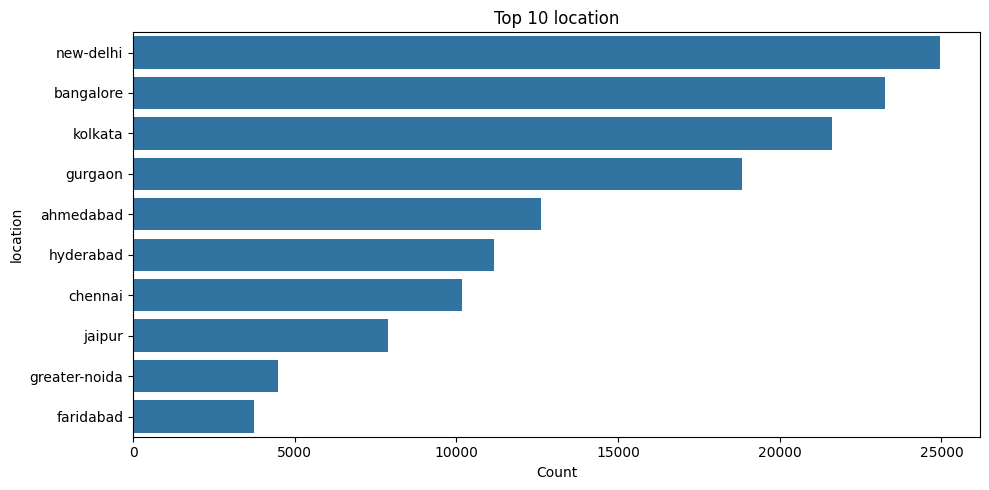

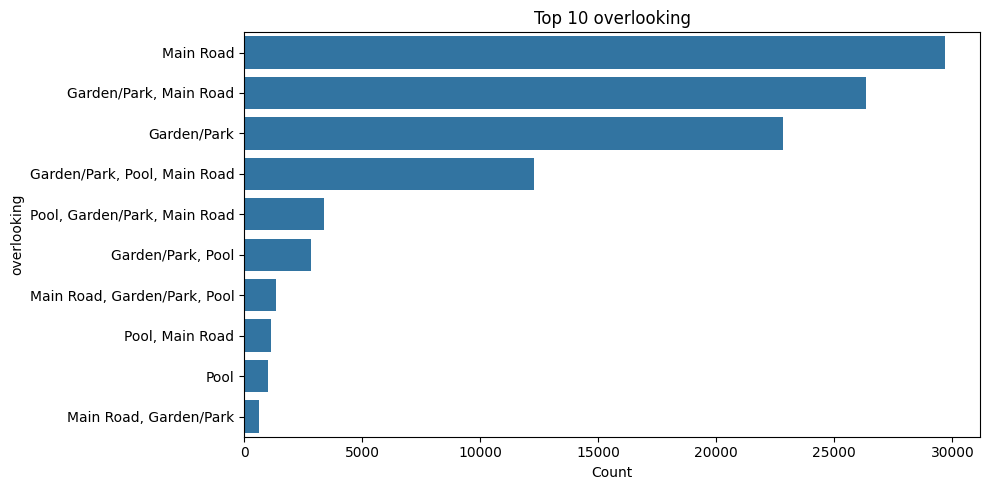

In [32]:
for col in large_plot_cols:
    top = df[col].value_counts().head(10)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=top.values, y=top.index)
    plt.title(f'Top 10 {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Categorical Features

- `Transaction` is highly dominated by `Resale`, with `Rent/Lease` being almost absent.
- `Ownership` is highly dominated by `Freehold`.
- `Overlooking` has many different combinations, with several very rare categories.

In [33]:
top_loc = df['location'].value_counts().head(50).index
df['location'] = df['location'].where(df['location'].isin(top_loc), 'Other')

df['location'].nunique()

51

In [34]:
semi_cols = [
    'Carpet Area',
    'Floor',
    'Car Parking',
    'Super Area',
]
for col in semi_cols:
    print(df[col].dropna().value_counts().head(10))
    

Carpet Area
1000 sqft    5223
900 sqft     4616
1300 sqft    3446
1600 sqft    2737
600 sqft     2210
1500 sqft    2130
950 sqft     1912
1250 sqft    1651
400 sqft     1641
850 sqft     1637
Name: count, dtype: int64
Floor
1 out of 4    11801
2 out of 4    11437
3 out of 4     7804
1 out of 3     6934
2 out of 3     5868
4 out of 4     5814
3 out of 3     4405
2 out of 5     4331
4 out of 5     3723
3 out of 6     3579
Name: count, dtype: int64
Car Parking
1 Covered      37760
1 Covered,     16893
2 Covered      10020
1 Open          7697
2 Covered,      3968
2 Open          2560
10 Open          843
34 Covered       573
3 Covered        394
402 Covered      317
Name: count, dtype: int64
Super Area
1100 sqft    2567
1332 sqft    2110
1500 sqft    1998
500 sqft     1651
1000 sqft    1294
1450 sqft    1014
1300 sqft     990
1850 sqft     937
1250 sqft     903
1650 sqft     883
Name: count, dtype: int64


In [35]:
df.head(2)

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",4200000.0,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1.0,2.0,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,9800000.0,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2.0,NaN,1 Open,Freehold,NaN,NaN,NaN


## 5. Feature Engineering and Cleaning

Transforming text data into meaningful numerical features and handling unit conversions for area measurements.

In [36]:
print(df['Carpet Area'].dropna().astype(str).str.extract(r'([a-zA-Z]+)')[0].str.lower().value_counts())
print('-'*100)
print(df['Super Area'].dropna().astype(str).str.extract(r'([a-zA-Z]+)')[0].str.lower().value_counts())

0
sqft      95986
sqyrd      4658
sqm         870
acre          2
kanal         2
marla         2
bigha         1
ground        1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
0
sqft        71901
sqyrd        3463
sqm           854
marla           8
ground          3
kanal           3
aankadam        1
acre            1
cent            1
Name: count, dtype: int64


In [37]:
carpet_area = df["Carpet Area"].astype('str').str.strip().str.lower()
carpet_val = pd.to_numeric(carpet_area.str.extract(r'([\d.]+)')[0])
carpet_unit = carpet_area.str.extract(r'([a-zA-Z]+)')[0]
carpet_replace = {
    'sqft': 1,
    'sqyrd': 9,
    'sqm': 10.764,
    'acre': 43560,
    'hectare': 107639,
    'marla': 272.25,
    'kanal': 5445,
    'ground': 2400,
    'cent': 435.6,
    'aankadam': 72
}
df['Carpet Area'] = carpet_val * carpet_unit.map(carpet_replace)

In [38]:
super_area = df["Super Area"].astype('str').str.strip().str.lower()

super_val = pd.to_numeric(
    super_area.str.extract(r'([\d.]+)')[0],
    errors='coerce'
)

super_unit = super_area.str.extract(r'([a-zA-Z]+)')[0]

super_replace = {
    'sqft': 1,
    'sqyrd': 9,
    'sqm': 10.764,
    'acre': 43560,
    'hectare': 107639,
    'marla': 272.25,
    'kanal': 5445,
    'ground': 2400,
    'cent': 435.6,
    'aankadam': 72
}

df['Super Area'] = super_val * super_unit.map(super_replace)

In [39]:
df[['Carpet Area', 'Super Area']].describe()

,Carpet Area,Super Area
count,1.015210e+05,7.623500e+04
mean,1.935048e+03,2.286391e+03
std,2.050897e+05,1.684569e+05
min,1.000000e+00,1.000000e+00
25%,8.500000e+02,1.005000e+03
50%,1.100000e+03,1.288000e+03
75%,1.550000e+03,1.680000e+03
max,6.534000e+07,4.347288e+07


In [40]:
parts = df['Floor'].str.strip().str.split('out of')
df['Floor'] = pd.to_numeric(parts.str[0], errors='coerce')
df['Total Floors'] =  pd.to_numeric(parts.str[1], errors='coerce')

In [41]:
parking = df['Car Parking'].str.strip()
df['Parking Spaces'] = pd.to_numeric(parking.str.split().str[0], errors='coerce')
df['Is Covered'] = parking.str.contains('Covered', case=False).astype('Int64')

In [42]:
df[['Car Parking', 'Parking Spaces', 'Is Covered']].sample(10)

,Car Parking,Parking Spaces,Is Covered
128659,"1 Covered,",1.0,1
177713,NaN,NaN,<NA>
163314,1 Covered,1.0,1
80610,NaN,NaN,<NA>
17251,NaN,NaN,<NA>
150681,NaN,NaN,<NA>
116823,"1 Covered,",1.0,1
36306,NaN,NaN,<NA>
144995,NaN,NaN,<NA>
105002,1 Covered,1.0,1


### Dropping Unnecessary Columns

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              177847 non-null  int64  
 1   Title              177847 non-null  object 
 2   Description        174918 non-null  object 
 3   Amount(in rupees)  177847 non-null  float64
 4   Price (in rupees)  169866 non-null  float64
 5   location           177847 non-null  object 
 6   Carpet Area        101521 non-null  float64
 7   Status             177252 non-null  object 
 8   Floor              159979 non-null  float64
 9   Transaction        177780 non-null  object 
 10  Furnishing         175780 non-null  object 
 11  facing             112111 non-null  object 
 12  overlooking        102022 non-null  object 
 13  Society            74928 non-null   object 
 14  Bathroom           177087 non-null  float64
 15  Balcony            130688 non-null  float64
 16  Car Par

### Handle Outliers

In [44]:
price_per_sqft = df['Price (in rupees)'].dropna()

lower = price_per_sqft.quantile(0.01)
upper = price_per_sqft.quantile(0.99)

print(f'1st percentile : {lower} \n 99th percentile {upper}')

1st percentile : 2228.0 
 99th percentile 23810.0


In [45]:
outliers = (df['Price (in rupees)'] < lower) | (df['Price (in rupees)'] > upper)
print('Rows to remove:', outliers.sum())

Rows to remove: 2972


In [46]:
df = df.loc[~outliers]

In [47]:
df[['Carpet Area', 'Floor', 'Total Floors',
    'Bathroom', 'Balcony', 'Super Area',
    'Parking Spaces']].describe().T

,count,mean,std,min,25%,50%,75%,max
Carpet Area,100147.0,1939.549376,206489.711834,1.0,850.0,1100.0,1550.0,65340000.0
Floor,157588.0,4.769361,4.624487,1.0,2.0,3.0,6.0,200.0
Total Floors,168294.0,8.710744,7.371494,1.0,4.0,5.0,11.0,200.0
Bathroom,174141.0,2.445225,0.850191,1.0,2.0,2.0,3.0,11.0
Balcony,128849.0,2.010462,0.952613,1.0,1.0,2.0,3.0,11.0
Super Area,74637.0,1369.498932,632.310115,10.0,1013.0,1285.0,1675.0,10890.0
Parking Spaces,80223.0,4.012104,31.636521,1.0,1.0,1.0,1.0,999.0


#### Carpet Area Column

In [48]:
df[['Carpet Area', 'Super Area', 'Amount(in rupees)']].corr()

,Carpet Area,Super Area,Amount(in rupees)
Carpet Area,1.000000,NaN,0.000913
Super Area,NaN,1.000000,0.707029
Amount(in rupees),0.000913,0.707029,1.000000


<Axes: ylabel='Carpet Area'>

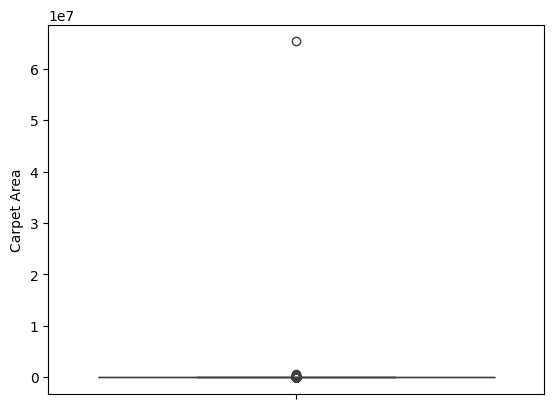

In [49]:
sns.boxplot(df['Carpet Area'])

In [50]:
df.loc[df['Carpet Area'] > 10000,
       ['Carpet Area', 'Super Area', 'Amount(in rupees)']].sort_values('Carpet Area', ascending=False)

,Carpet Area,Super Area,Amount(in rupees)
93644,6.534000e+07,NaN,5500000.0
165733,7.092220e+05,NaN,6000000.0
149239,4.959700e+05,NaN,1900000.0
50895,1.949360e+05,NaN,26000000.0
147791,1.131340e+05,NaN,5600000.0
82876,1.078060e+05,NaN,6800000.0
180072,8.184500e+04,NaN,4500000.0
176689,8.167500e+04,NaN,4570000.0
153711,7.200900e+04,NaN,3600000.0
176690,7.177500e+04,NaN,4020000.0


In [51]:
df.loc[df['Carpet Area'] > 10000, 'Carpet Area'] = np.nan

In [52]:
df['Carpet Area'].max()

10000.0

#### Floor Column

In [53]:
print(df.loc[df['Floor'] > 10 , ['Floor', 'Total Floors']].sort_values('Total Floors',ascending=False).head(15))
print('-'* 100)
print(df.loc[df['Floor'] > df['Total Floors'], ['Floor', 'Total Floors']])

        Floor  Total Floors
167821  200.0         200.0
143885   11.0          84.0
143288   33.0          72.0
143341   33.0          72.0
2583     32.0          61.0
115071   32.0          61.0
1817     28.0          60.0
2584     40.0          60.0
114308   28.0          60.0
1941     17.0          60.0
114432   17.0          60.0
115072   40.0          60.0
114248   25.0          55.0
2530     12.0          55.0
1756     25.0          55.0
----------------------------------------------------------------------------------------------------
        Floor  Total Floors
72673     6.0           2.0
113564    4.0           2.0
158590    4.0           3.0


In [54]:
df.loc[df['Floor'] > df['Total Floors'], 'Floor'] = np.nan

In [55]:
df.loc[df['Floor'] > df['Total Floors'], ['Floor', 'Total Floors']]

,Floor,Total Floors


In [56]:
df.loc[df['Floor'] > 50, ['Floor', 'Total Floors']].sort_values('Total Floors', ascending = False)

,Floor,Total Floors
167821,200.0,200.0


In [57]:
df.loc[df['Floor'] == 200, 'Floor'] = np.nan
df.loc[df['Total Floors'] == 200, 'Total Floors'] = np.nan

#### Bathroom and Balcony Columns


In [58]:
print(df.loc[df['Bathroom'] > 10, 'Bathroom'].value_counts(ascending=False))
print('-'*100)
print(df.loc[df['Balcony'] > 10, 'Balcony'].value_counts(ascending=False))

Bathroom
11.0    22
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Balcony
11.0    10
Name: count, dtype: int64


### Parking Spaces Column

In [59]:
df.loc[df['Parking Spaces'] > 20,
       ['Parking Spaces', 'Is Covered', 'Amount(in rupees)']].sort_values('Parking Spaces', ascending=False).head(5)

,Parking Spaces,Is Covered,Amount(in rupees)
83932,999.0,1,4000000.0
160316,908.0,1,6950000.0
52152,903.0,1,9600000.0
166051,901.0,1,5500000.0
155338,835.0,1,4000000.0


In [60]:
df.loc[df['Parking Spaces'] > 35, 'Parking Spaces'].value_counts().head(20)

Parking Spaces
402.0    315
103.0     11
101.0     10
100.0     10
50.0       9
302.0      7
401.0      7
201.0      7
202.0      6
203.0      6
301.0      6
303.0      6
102.0      5
300.0      5
305.0      4
180.0      4
505.0      4
45.0       4
503.0      4
204.0      4
Name: count, dtype: int64

In [61]:
df.loc[df['Parking Spaces'] > 35, 'Parking Spaces'] = np.nan

In [62]:
df = df.drop(columns=['Plot Area', 'Dimensions', 'Status', 'Index', 'Society', 'Car Parking', 'Price (in rupees)', 'Title', 'Description'])

## 6. Data Splitting

In [63]:
X = df.drop(columns='Amount(in rupees)')
y = df['Amount(in rupees)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

y_train_log = np.log1p(y_train)

In [64]:
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

In [65]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((139900, 14), (34975, 14), (139900,), (34975,))

## 7. Data Preprocessing and Pipeline

In [66]:
num = Pipeline([
    ('impute', SimpleImputer(strategy = 'median', add_indicator=True)),
    ('scale', StandardScaler())
])
cat = Pipeline([
    ('impute', SimpleImputer(strategy = 'most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', num, num_cols),
    ('cat', cat, cat_cols)
])

In [67]:
X_train_prepared = preprocess.fit_transform(X_train)
X_test_prepared = preprocess.transform(X_test)

In [68]:
X_train_prepared.shape, X_test_prepared.shape

((139900, 104), (34975, 104))

## 8. Model Training, Selection & Evaluation

I train multiple regression models (Linear Regression, Random Forest, and Gradient Boosting) and compare their performance using metrics like MAE, RMSE, and R2-Score.

In [69]:
models = {
    'Linear Regression': LinearRegression(),
    
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('prep', preprocess),
        ('model', model)
    ])
    
    print(f'\nTraining {name}...')
    pipeline.fit(X_train, y_train_log)
    trained_models[name] = pipeline
    print('Trained successfully :)')


Training Linear Regression...
Trained successfully :)

Training Random Forest...
Trained successfully :)

Training Gradient Boosting...
Trained successfully :)


In [70]:
predictions = {}

for name, model in trained_models.items():
    pred_log = model.predict(X_test)
    pred = np.expm1(pred_log)
    predictions[name] = pred

In [71]:
results = []

for name, pred in predictions.items():
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': root_mean_squared_error(y_test, pred),
        'R2': r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)

results_df

,Model,MAE,RMSE,R2
1,Random Forest,8.302809e+05,3.455255e+06,0.910648
2,Gradient Boosting,2.149678e+06,4.631656e+06,0.839447
0,Linear Regression,4.066831e+06,2.302467e+07,-2.967640


In [72]:
pipeline_rf = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

cv_scores = cross_val_score(pipeline_rf, X_train, y_train_log, cv=5, scoring='r2')

print('Cross Validation R2 scores', cv_scores)

Cross Validation R2 scores [0.94452968 0.9450958  0.94264598 0.94415672 0.94256111]


In [73]:
rf_pipeline = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 10, 20, 30, 40],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': [1.0, 'sqrt', 'log2'],
    'model__bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train_log)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END model__bootstrap=True, model__max_depth=30, model__max_features=log2, model__min_samples_leaf=4, model__min_samples_split=2, model__n_estimators=500; total time= 5.5min
[CV] END model__bootstrap=False, model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=500; total time= 2.0min
[CV] END model__bootstrap=False, model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=500; total time= 2.0min
[CV] END model__bootstrap=False, model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=500; total time= 2.0min
[CV] END model__bootstrap=False, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=100; total time= 4.3min
[CV] END model__bootstrap=False, model__

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__bootstrap=False, model__max_depth=None, model__max_features=1.0, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=28.4min
[CV] END model__bootstrap=False, model__max_depth=40, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=500; total time=24.4min
[CV] END model__bootstrap=True, model__max_depth=30, model__max_features=log2, model__min_samples_leaf=4, model__min_samples_split=2, model__n_estimators=500; total time= 5.5min
[CV] END model__bootstrap=False, model__max_depth=None, model__max_features=1.0, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=27.1min
[CV] END model__bootstrap=False, model__max_depth=40, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=500; total time=24.6min


KeyboardInterrupt: 

In [75]:
print('Best Parameters:')
print(random_search.best_params_)

print('\nBest CV R2:')
print(random_search.best_score_)

Best Parameters:


AttributeError: 'RandomizedSearchCV' object has no attribute 'best_params_'

In [81]:
best_model = trained_models['Random Forest']


joblib.dump(best_model, 'House_price.pkl')

print('Model saved!')

Model saved!


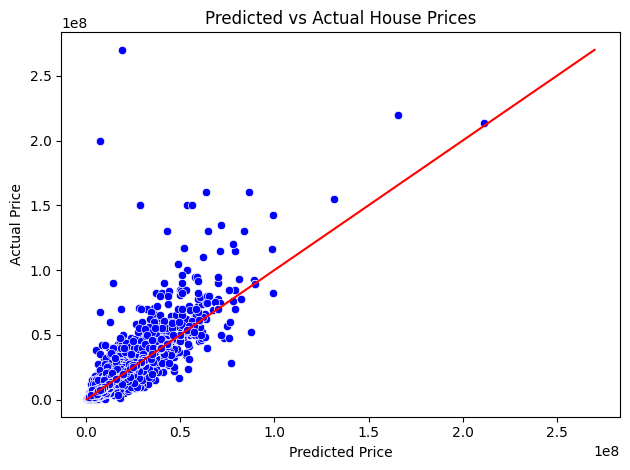

In [102]:
predictions = np.expm1(best_model.predict(X_test))
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())

sns.scatterplot(x=predictions, y=y_test, c='b')

plt.plot([min_val, max_val], [min_val, max_val], c = 'r')

plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
plt.title("Predicted vs Actual House Prices")
plt.tight_layout()   
plt.show()

## 9. Model inference

In [83]:
model_test = joblib.load('House_price.pkl')


Loaded Model Prediction: 16202510.427377876


In [90]:
test = X_test.iloc[[1]]
pred_log = model_test.predict(test)
pred = np.expm1(pred_log)
true = y_test.iloc[1]

print(f"Prediction: {pred[0]}")
print(f"True Value: {true}")

Prediction: 5523656.004948874
True Value: 5200000.0


In [113]:
locations= sorted(df['location'].dropna().unique().tolist())


with open('locations.json', 'w') as f:
    json.dump(locations, f, indent=2)

In [114]:
display(FileLink('House_price.pkl'))
display(FileLink('locations.json'))

/kaggle/working/House_price.pkl

/kaggle/working/locations.json

In [115]:
import os

size_mb = os.path.getsize('House_price.pkl') / (1024 ** 2)

print(f'Model size: {size_mb:.2f} MB')

Model size: 831.62 MB


## 10. Project Resources

- **Data Source:** [Kaggle House Price Dataset](https://www.kaggle.com/datasets/juhibhojani/house-price)
- **Tools:** Numpy, Pandas, Matplotlib, Seaborn, Scikit-learn